In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

In [2]:
print(torch.__version__)
print(torchvision.__version__)

2.9.1+cu128
0.24.1+cu128


In [3]:
path = '/home/aj/GenAI/Machine_Learninng_pytorch/deep_learning/Classification_by_RNN/Data'

train_data = datasets.FashionMNIST(root=path,
                                   train=True, 
                                   download=True,
                                   transform=ToTensor(), 
                                   target_transform=None)
test_data = datasets.FashionMNIST(root=path, 
                                  download=True,
                                  train=False,
                                  target_transform=None,
                                  transform=ToTensor())

In [4]:
train_data[0], train_data[1]

((tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
            0.2863, 0.0000, 0

In [5]:
train_images, train_labels = train_data[0]
class_names = train_data.class_to_idx
class_names = {value: key for key, value in class_names.items()}
class_names

{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

In [6]:
train_images.shape, train_labels

(torch.Size([1, 28, 28]), 9)

Text(0.5, 1.0, '9')

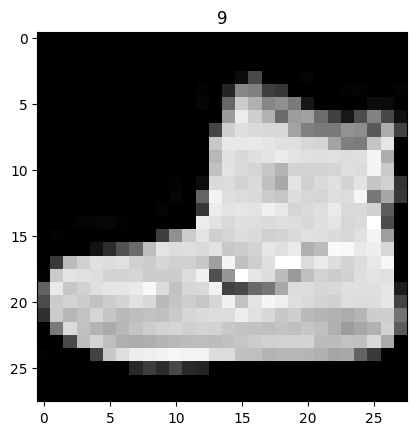

In [7]:
# visualize
plt.imshow(train_images.squeeze(), cmap='gray')
plt.title(train_labels)

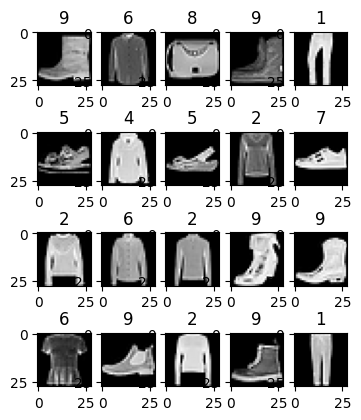

In [8]:
torch.manual_seed(42)
rows, columns = 4,5
fig = plt.figure(figsize=(rows, columns))

for i in range(1, rows*columns+1):
    random_index = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_index]
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.squeeze(), cmap='grey')
    plt.title(label=label)
    

# Linear model or Non Linear model

In [9]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: /home/aj/GenAI/Machine_Learninng_pytorch/deep_learning/Classification_by_RNN/Data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: /home/aj/GenAI/Machine_Learninng_pytorch/deep_learning/Classification_by_RNN/Data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [10]:
# Load dataset
# if all images are loaded at once, the system might run out of resources
# so we break the dataset into batches (60000 total trainable images into 32-image batch size each)
# it also gives our model to updatethe  gradient after every 32 images (mini batch gradient descent)
from torch.utils.data import DataLoader

In [11]:
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7e702f906e00>,
 <torch.utils.data.dataloader.DataLoader at 0x7e702f904fa0>)

In [12]:
len(train_dataloader)

1875

In [13]:
print(f'no of batches for training are: {len(train_dataloader)} & no of batches for testing are: {len(test_dataloader)}')

no of batches for training are: 1875 & no of batches for testing are: 313


In [14]:
# simple example to understand iterator in Python.
a = [1,2,3,4,5]
x = iter(a)
next(x),next(x),next(x),next(x),next(x)

(1, 2, 3, 4, 5)

In [15]:
# let's interact withthe  data loader 
# try to fetch a batch and visualize a batch

train_feature_batch, train_label_batch = next(iter(train_dataloader))
train_feature_batch.shape, train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [16]:
train_label_batch[0]

tensor(5)

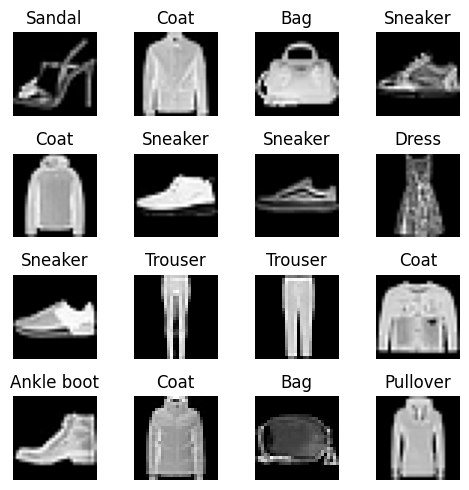

In [17]:
plt.figure(figsize=(5, 5))

for i in range(16):  # show first 16 images
    plt.subplot(4, 4, i + 1)
    plt.imshow(train_feature_batch[i].squeeze(), cmap="gray")
    plt.title(class_names[train_label_batch[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

# MODEL 0 -> LINEAR MODEL 

In [18]:
# make model | starting with base line model (simple model -> later develop after experimentation)

class FashionMnist0(nn.Module):
    def __init__(self, input_shapes:int, hidden_units:int ,output_shapes:int):
        super().__init__()
        self.layers_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shapes, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shapes),
        )
        
    def forward(self, X):
        return self.layers_stack(X)

torch.manual_seed(42)
model_0 = FashionMnist0(input_shapes=28*28, hidden_units=10, output_shapes=len(class_names))

In [19]:
model_0

FashionMnist0(
  (layers_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [20]:
model_0.state_dict()

OrderedDict([('layers_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layers_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layers_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, 

In [21]:

"""
A series of helper functions used throughout the course.

If a function gets defined once and could be used over and over, it'll go in here.
"""
import torch
import matplotlib.pyplot as plt
import numpy as np

from torch import nn

import os
import zipfile

from pathlib import Path

import requests

# Walk through an image classification directory and find out how many files (images)
# are in each subdirectory.
import os

def walk_through_dir(dir_path):
    """
    Walks through dir_path returning its contents.
    Args:
    dir_path (str): target directory

    Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


# Plot linear data or training and test and predictions (optional)
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})


# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


def print_train_time(start, end, device=None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"\nTrain time on {device}: {total_time:.3f} seconds")
    return total_time


# Plot loss curves of a model
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()


# Pred and plot image function from notebook 04
# See creation: https://www.learnpytorch.io/04_pytorch_custom_datasets/#113-putting-custom-image-prediction-together-building-a-function
from typing import List
import torchvision


def pred_and_plot_image(
    model: torch.nn.Module,
    image_path: str,
    class_names: List[str] = None,
    transform=None,
    device: torch.device = "cuda" if torch.cuda.is_available() else "cpu",
):
    """Makes a prediction on a target image with a trained model and plots the image.

    Args:
        model (torch.nn.Module): trained PyTorch image classification model.
        image_path (str): filepath to target image.
        class_names (List[str], optional): different class names for target image. Defaults to None.
        transform (_type_, optional): transform of target image. Defaults to None.
        device (torch.device, optional): target device to compute on. Defaults to "cuda" if torch.cuda.is_available() else "cpu".
    
    Returns:
        Matplotlib plot of target image and model prediction as title.

    Example usage:
        pred_and_plot_image(model=model,
                            image="some_image.jpeg",
                            class_names=["class_1", "class_2", "class_3"],
                            transform=torchvision.transforms.ToTensor(),
                            device=device)
    """

    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255.0

    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(
        target_image.squeeze().permute(1, 2, 0)
    )  # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False)

def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

def download_data(source: str, 
                  destination: str,
                  remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source (str): A link to a zipped file containing data.
        destination (str): A target directory to unzip data to.
        remove_source (bool): Whether to remove the source after downloading and extracting.
    
    Returns:
        pathlib.Path to downloaded data.
    
    Example usage:
        download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")
    """
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...") 
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)
    
    return image_path


/home/aj/miniconda3/envs/genai/lib/python3.10/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [22]:
# send dummy data to model 
dummy_image = torch.rand([1,1,28,28])
dummy_image.shape

torch.Size([1, 1, 28, 28])

In [23]:
model_0.eval()
with torch.inference_mode():
    y = model_0(dummy_image)
y

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]])

In [24]:
# loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

# TIME MANAGMENT
# ACCURACY VS SPEED

In [25]:
from timeit import default_timer as timer
def print_train_time(start:float, end:float, device:torch.device=None):
    """returns time taken by loop"""
    total_time = end-start
    # print(f'Train time on {device}: {total_time:.3f} seconds')

    return f'Train time on {device}: {total_time:.3f} seconds'

In [26]:
# training and testing loop
# 1. loop through epochs
# 2. loop through training batches, perform training step, calculate train loss (per batch)
# 3. loop through testing batches, perform testing step, calculate test loss (per batch)
# 4. print whats'is happening

In [27]:
# make aprogress bar
from tqdm.auto import tqdm

In [28]:
# manual seeding example

torch.manual_seed(42)
a = torch.rand([2,2])

# torch.manual_seed(42)
b = torch.rand([2,2])

a,b

(tensor([[0.8823, 0.9150],
         [0.3829, 0.9593]]),
 tensor([[0.3904, 0.6009],
         [0.2566, 0.7936]]))

In [29]:
# enumerator explained
a = ["a","b","c","d","e"]

for idx, element in enumerate(a):
    print(f'elment at position{idx} is: {element}')

elment at position0 is: a
elment at position1 is: b
elment at position2 is: c
elment at position3 is: d
elment at position4 is: e


In [30]:
torch.manual_seed(42)

start_time = timer()
epochs = 10

# loop to traverse through epochs
for epoch in tqdm(range(epochs)):
    print(f'Epoch #: {epoch+1}\n------')

    # loop to traverse through batches
    train_loss_accumulated = 0 #for accumulation of training loss over an epoch
    for batch_idx, (train_image,train_label) in enumerate(train_dataloader):
        model_0.train()
        # forward pass
        y_pred_train = model_0(train_image)

        # calculate loss
        loss = loss_fn(y_pred_train,train_label)
        train_loss_accumulated += loss   # to get loss per batch | accumulate train loss

        # optimize zero grad
        optimizer.zero_grad()

        # loss backward
        loss.backward()

        # optimizer step
        optimizer.step()

        if batch_idx % 400 == 0 :
            print(f'looked at {batch_idx * len(train_image)}/{len(train_dataloader.dataset)} samples')

    avg_train_loss = train_loss_accumulated / len(train_dataloader) # averaging loss (sum of all the items divided by total no of items)

    test_loss_accumulated, test_acc_accumulated = 0,0 #for accumulation of training loss and training accuracy over an epoch
    # testing loop
    model_0.eval()
    with torch.inference_mode():
        for test_image, test_label in test_dataloader:
            
            # forward pass
            y_pred_test = model_0(test_image)

            # calculate loss
            test_loss_accumulated += loss_fn(y_pred_test, test_label)

            # calculate accuracy
            test_acc_accumulated += accuracy_fn(y_pred=y_pred_test.argmax(dim=1), y_true=test_label)

    avg_test_loss = test_loss_accumulated / len(test_dataloader)
    avg_test_accuracy =  test_acc_accumulated / len(test_dataloader)

    print(f'\nTrain Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} & Test Acc: {avg_test_accuracy:.4f}% \n')
                
end_time = timer()

print(print_train_time(start=start_time, end=end_time, device='cpu'))

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch #: 1
------
looked at 0/60000 samples
looked at 12800/60000 samples
looked at 25600/60000 samples
looked at 38400/60000 samples
looked at 51200/60000 samples

Train Loss: 0.5904 | Test Loss: 0.5095 & Test Acc: 82.0387% 

Epoch #: 2
------
looked at 0/60000 samples
looked at 12800/60000 samples
looked at 25600/60000 samples
looked at 38400/60000 samples
looked at 51200/60000 samples

Train Loss: 0.4763 | Test Loss: 0.4799 & Test Acc: 83.1969% 

Epoch #: 3
------
looked at 0/60000 samples
looked at 12800/60000 samples
looked at 25600/60000 samples
looked at 38400/60000 samples
looked at 51200/60000 samples

Train Loss: 0.4550 | Test Loss: 0.4766 & Test Acc: 83.4265% 

Epoch #: 4
------
looked at 0/60000 samples
looked at 12800/60000 samples
looked at 25600/60000 samples
looked at 38400/60000 samples
looked at 51200/60000 samples

Train Loss: 0.4425 | Test Loss: 0.4631 & Test Acc: 83.7460% 

Epoch #: 5
------
looked at 0/60000 samples
looked at 12800/60000 samples
looked at 25600/60

In [31]:
# train_feature_batch, train_label_batch = next(iter(train_dataloader))
# train_feature_batch.shape, train_label_batch.shape


# make a general function so that different models can be compared in standard way
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn):
    """Return model performance"""
    loss_accumulated, accuracy_accumulated = 0,0
    model.eval()
    with torch.inference_mode():
        for X,y in tqdm(data_loader):
            y_pred = model(X)
            current_loss = loss_fn(y_pred, y)
            current_acc =  accuracy_fn(y_pred=y_pred.argmax(dim=1), y_true=y)
            loss_accumulated += current_loss
            accuracy_accumulated += current_acc
        avg_loss = loss_accumulated /len(data_loader)
        avg_acc = accuracy_accumulated /len(data_loader)

    return {"Model_class_name":model.__class__.__name__,
            'Loss':avg_loss.item(),
            'Accuracy':avg_acc}
    

In [32]:
model0_performance = eval_model(model=model_0, data_loader=test_dataloader, accuracy_fn=accuracy_fn, loss_fn=loss_fn)

  0%|          | 0/313 [00:00<?, ?it/s]

# MODEL 1 -> NON LINEAR MODEL 

In [33]:
# model with nonlinearities
class FashionMnist1(nn.Module):
    def __init__(self, input_features:int, hidden_neurons:int = 8, output_features:int=10):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_features, out_features=hidden_neurons),
            nn.ReLU(),
            nn.Linear(in_features=hidden_neurons, out_features=output_features)
        )

    def forward(self, X):
        return self.layer_stack(X)

model_1 = FashionMnist1(input_features=28*28, hidden_neurons=8, output_features=len(class_names))

In [34]:
model_1

FashionMnist1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=8, bias=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=10, bias=True)
  )
)

In [35]:
model_1.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[-0.0078,  0.0072, -0.0174,  ..., -0.0354,  0.0187,  0.0085],
                      [-0.0182,  0.0344, -0.0162,  ...,  0.0017,  0.0045,  0.0133],
                      [-0.0108, -0.0213,  0.0084,  ...,  0.0273, -0.0081,  0.0026],
                      ...,
                      [ 0.0350, -0.0151, -0.0171,  ...,  0.0005,  0.0119,  0.0352],
                      [-0.0116, -0.0145,  0.0259,  ...,  0.0273, -0.0344,  0.0127],
                      [-0.0325,  0.0155,  0.0087,  ...,  0.0257,  0.0291,  0.0243]])),
             ('layer_stack.1.bias',
              tensor([-0.0006,  0.0088,  0.0018, -0.0136, -0.0354, -0.0044,  0.0154,  0.0208])),
             ('layer_stack.3.weight',
              tensor([[ 0.0841,  0.1612,  0.2213, -0.0684,  0.2309, -0.0074, -0.1252, -0.1373],
                      [-0.2061, -0.2723,  0.0810,  0.3267,  0.0503,  0.0478, -0.1326, -0.1394],
                      [-0.1108,  0.1224,  0.0610, -0.1299,  0.069

In [59]:
# training & testing loop

# make a function of the training loop
def training_step(model:nn.Module,
                 data_loader:torch.utils.data.DataLoader,
                 loss_fn:torch.nn.Module,
                 optimizer:torch.optim.Optimizer,
                 ):
    model.train()
    train_loss_accumulated, train_acc_accumulated = 0,0 #for accumulation of training loss over an epoch
    for X,y in data_loader:
        
        # forward pass
        y_pred_train = model(X)

        # calculate loss
        loss = loss_fn(y_pred_train,y)
        train_loss_accumulated += loss   # to get loss per batch | accumulate train loss
        # calculate accuracy
        train_acc_accumulated += accuracy_fn(y_pred=y_pred_train.argmax(dim=1), y_true=y)        

        # optimize zero grad
        optimizer.zero_grad()

        # loss backward
        loss.backward()

        # optimizer step
        optimizer.step()

    avg_train_loss = train_loss_accumulated / len(data_loader)
    avg_train_acc = train_acc_accumulated / len(data_loader)

    print(f'Train Loss: {avg_train_loss:.5f} & Train Accuracy:{avg_train_acc:.2f}%\n')

def testing_step(model:nn.Module,
                 data_loader:torch.utils.data.DataLoader,
                 loss_fn:torch.nn.Module,
                 optimizer:torch.optim.Optimizer,
                 ):
    test_loss_accumulated, test_acc_accumulated = 0,0
    # testing loop
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            
            # forward pass
            y_pred_test = model(X)

            # calculate loss
            test_loss_accumulated += loss_fn(y_pred_test, y)

            # calculate accuracy
            test_acc_accumulated += accuracy_fn(y_pred=y_pred_test.argmax(dim=1), y_true=y)

        avg_test_loss = test_loss_accumulated / len(data_loader)
        avg_test_accuracy =  test_acc_accumulated / len(data_loader)

        print(f'Test Loss: {avg_test_loss:.5f} | Test Accuracy: {avg_test_accuracy:.2f}%\n')


In [60]:
# model1 training

start_time = timer()
epochs = 3
for epoch in range(epochs):
    print(f'Epoch:{epoch}\n---------')
    training_step(model=model_1, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer)

    testing_step(model=model_1, data_loader=test_dataloader,loss_fn=loss_fn, optimizer=optimizer)

end_time = timer()

print_train_time(start=start_time, end=end_time, device='cpu')

Epoch:0
---------
Train Loss: 2.34155 & Train Accuracy:11.89%

Test Loss: 2.34080 | Test Accuracy: 12.30%

Epoch:1
---------
Train Loss: 2.34155 & Train Accuracy:11.89%

Test Loss: 2.34080 | Test Accuracy: 12.30%

Epoch:2
---------
Train Loss: 2.34155 & Train Accuracy:11.89%

Test Loss: 2.34080 | Test Accuracy: 12.30%



'Train time on cpu: 21.151 seconds'

In [61]:
model1_performance = eval_model(model=model_1, loss_fn=loss_fn, data_loader=test_dataloader, accuracy_fn=accuracy_fn)

  0%|          | 0/313 [00:00<?, ?it/s]

# MODEL 2 -> CONVOLUTIONAL NEURAL NETWORK MODEL (tiny VGG)

In [101]:
# model with convolutional layers 
class FashionMnist2(nn.Module):
    def __init__(self, input_shape:int, hidden_neurons:int = 8, output_shape:int=10):
        super().__init__()
        # 1st Block = feature extractor
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_neurons,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_neurons,
                      out_channels=hidden_neurons,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
            
        # 2nd Block =  feature extractor
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_neurons,
                      out_channels=hidden_neurons,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_neurons,
                      out_channels=hidden_neurons,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        # 3rd Block = classififer
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_neurons * 7 * 7  , out_features=output_shape)
        )

    def forward(self, X):
        # print("Input:", X.shape)
        X = self.conv_block_1(X)
        # print("After block 1:", X.shape)
        X = self.conv_block_2(X)
        # print("After block 2:", X.shape)
        X = self.classifier(X)
        # print("Output:", X.shape)
        return X

In [102]:
torch.manual_seed(42)
model_2 = FashionMnist2(input_shape=1, hidden_neurons=10, output_shape=len(class_names))

In [103]:
# create random image of size (1,28,28)
dummy_image = torch.rand(1,28,28).unsqueeze(0)

In [104]:
dummy_image.shape

torch.Size([1, 1, 28, 28])

In [105]:
# plt.imshow(dummy_image.squeeze(), cmap="gray")

In [106]:
# lets pas this image from the model
model_2.eval()
with torch.inference_mode():
        y_pred_test = model_2(dummy_image)
y_pred_test

tensor([[ 0.0372, -0.0748,  0.0573, -0.0396, -0.0098,  0.0194, -0.0003, -0.0114,
          0.0206,  0.0003]])

In [107]:
# make loss funtion and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer  = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [108]:
# training and testing loop

torch.manual_seed(42)

start_time = timer()
epochs = 10

# loop to traverse through epochs
for epoch in tqdm(range(epochs)):
    print(f'Epoch #: {epoch+1}\n------')
    training_step(model=model_2, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer)
    testing_step(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, optimizer=optimizer)
                    
end_time = timer()

print(print_train_time(start=start_time, end=end_time, device='cpu'))

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch #: 1
------
Train Loss: 0.59765 & Train Accuracy:78.34%

Test Loss: 0.39174 | Test Accuracy: 85.89%

Epoch #: 2
------
Train Loss: 0.36025 & Train Accuracy:87.07%

Test Loss: 0.35624 | Test Accuracy: 86.38%

Epoch #: 3
------
Train Loss: 0.32263 & Train Accuracy:88.33%

Test Loss: 0.32829 | Test Accuracy: 88.01%

Epoch #: 4
------
Train Loss: 0.30252 & Train Accuracy:88.97%

Test Loss: 0.31542 | Test Accuracy: 87.98%

Epoch #: 5
------
Train Loss: 0.28761 & Train Accuracy:89.54%

Test Loss: 0.30334 | Test Accuracy: 88.79%

Epoch #: 6
------
Train Loss: 0.27718 & Train Accuracy:90.06%

Test Loss: 0.30906 | Test Accuracy: 89.09%

Epoch #: 7
------
Train Loss: 0.27035 & Train Accuracy:90.20%

Test Loss: 0.30403 | Test Accuracy: 89.29%

Epoch #: 8
------
Train Loss: 0.26493 & Train Accuracy:90.31%

Test Loss: 0.29441 | Test Accuracy: 89.61%

Epoch #: 9
------
Train Loss: 0.25740 & Train Accuracy:90.78%

Test Loss: 0.31068 | Test Accuracy: 89.52%

Epoch #: 10
------
Train Loss: 0.2545

In [109]:
model2_performance = eval_model(model=model_2, loss_fn=loss_fn, data_loader=test_dataloader, accuracy_fn=accuracy_fn)

  0%|          | 0/313 [00:00<?, ?it/s]

In [110]:
print(f'{model0_performance}\n{model1_performance}\n{model2_performance}')

{'Model_class_name': 'FashionMnist0', 'Loss': 0.4627982974052429, 'Accuracy': 83.64616613418531}
{'Model_class_name': 'FashionMnist1', 'Loss': 2.3407959938049316, 'Accuracy': 12.300319488817891}
{'Model_class_name': 'FashionMnist2', 'Loss': 0.29679355025291443, 'Accuracy': 89.36701277955271}


In [111]:
import pandas as pd

In [112]:
df = pd.DataFrame([model0_performance, model1_performance, model2_performance])
df

,Model_class_name,Loss,Accuracy
0,FashionMnist0,0.462798,83.646166
1,FashionMnist1,2.340796,12.300319
2,FashionMnist2,0.296794,89.367013


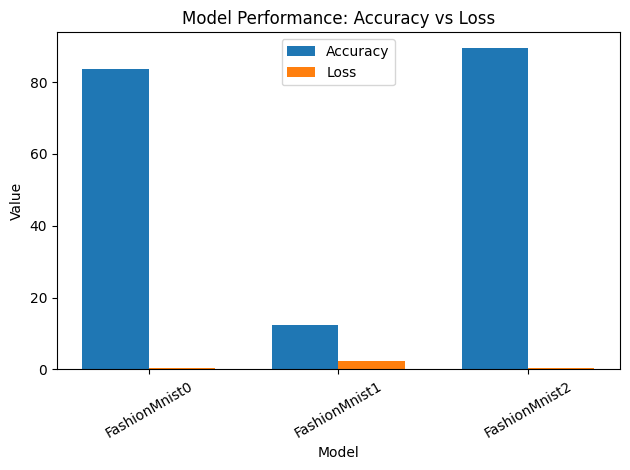

In [113]:
# can also add training time
models = df["Model_class_name"]
accuracy = df["Accuracy"]
loss = df["Loss"]

x = np.arange(len(models))   # label locations
width = 0.35                 # width of the bars

plt.figure()

plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, loss, width, label="Loss")

plt.xticks(x, models, rotation=30)
plt.xlabel("Model")
plt.ylabel("Value")
plt.title("Model Performance: Accuracy vs Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [57]:
# make predictions from test data

# show images with true class as label and predicted class as label

In [114]:
# evaluate other matrices like confusion matrix
# visualize the confusion matrix 